imports...

In [52]:

import pandas as pd
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
df = pd.read_parquet("plant_pictures.parquet")

In [3]:
df.to_csv("dataset.csv", index=False)

In [4]:
df

,image,mask,crop_type,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,idb,healthy
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,zx1,stressed
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,ida,stressed
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,bx,stressed
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,bx,stressed
...,...,...,...,...
6122,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,ida,stressed
6123,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,by,healthy
6124,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,"{'bytes': b""\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...",zx1,stressed
6125,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,tu3,healthy


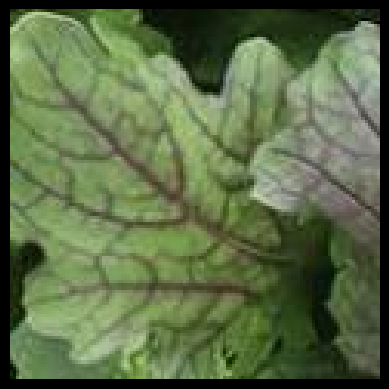

In [5]:
df = pd.read_parquet("plant_pictures.parquet")

image_data = df.iloc[0]["image"]["bytes"]

img = Image.open(BytesIO(image_data))

plt.imshow(img)
plt.axis("off")
plt.show()

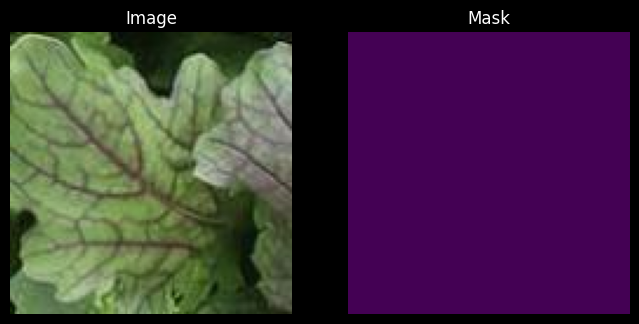

crop_type: idb
label: healthy


In [6]:
row = df.iloc[0]

img = Image.open(BytesIO(row["image"]["bytes"]))
mask = Image.open(BytesIO(row["mask"]["bytes"]))

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.title("Mask")
plt.axis("off")

plt.show()

print("crop_type:", row["crop_type"])
print("label:", row["label"])

In [7]:
df.describe()

,image,mask,crop_type,label
count,6127,6127,6127,6127
unique,6127,1889,14,2
top,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,zx1,healthy
freq,1,4238,958,3798


In [8]:
df.isnull().sum()

image        0
mask         0
crop_type    0
label        0
dtype: int64

In [9]:
print(df.head())
print(df.info())
print(df["label"].value_counts())
print(df["crop_type"].value_counts())

                                               image  \
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...   
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...   
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...   
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...   
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...   

                                                mask crop_type     label  
0  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...       idb   healthy  
1  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...       zx1  stressed  
2  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...       ida  stressed  
3  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...        bx  stressed  
4  {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...        bx  stressed  
<class 'pandas.DataFrame'>
RangeIndex: 6127 entries, 0 to 6126
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   image      6127 non-null   object
 

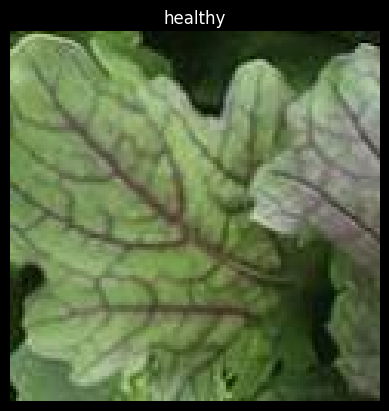

In [10]:
row = df.iloc[0]

img = Image.open(BytesIO(row["image"]["bytes"]))

plt.imshow(img)
plt.axis("off")
plt.title(row["label"])
plt.show()

Convert images into arrays

In [11]:
IMG_SIZE = 128

def decode_image(image_dict):
    img = Image.open(BytesIO(image_dict["bytes"])).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    arr = np.array(img)
    return arr

X = np.stack(df["image"].apply(decode_image).values)

print(X.shape)

(6127, 128, 128, 3)


Normalize images

Neural networks work better when values are between 0 and 1.

In [12]:
X = X.astype("float32") / 255.0

In [13]:
label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df["label"])

print(label_encoder.classes_)
print(y[:10])

['healthy' 'stressed']
[0 1 1 1 1 0 0 1 0 0]


0 = healthy , 1 = stressed

we will split into train validation and test
70% train
15% validation
15% test

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4288, 128, 128, 3)
Validation: (919, 128, 128, 3)
Test: (920, 128, 128, 3)


In [15]:
simple_nn = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(1, activation="sigmoid")
])

simple_nn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

simple_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,291,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,299,905 (24.03 MB)

 Trainable params: 6,299,905 (24.03 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history_simple = simple_nn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.5786 - loss: 1.4888 - val_accuracy: 0.6202 - val_loss: 0.6837
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.6199 - loss: 0.6780 - val_accuracy: 0.6202 - val_loss: 0.6728
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6199 - loss: 0.6700 - val_accuracy: 0.6202 - val_loss: 0.6665
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6199 - loss: 0.6662 - val_accuracy: 0.6202 - val_loss: 0.6647
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 7s 48ms/step - accuracy: 0.6199 - loss: 0.6647 - val_accuracy: 0.6202 - val_loss: 0.6641
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6199 - loss: 0.6638 - val_accuracy: 0.6202 - val_loss: 0.6640
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6199 - loss: 0.6649 - val_accuracy: 0.6202 - val_loss: 0.6640
Epoch 8/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6199 - loss: 0.6645 - val_accu

In [17]:
test_loss, test_acc = simple_nn.evaluate(X_test, y_test)

print("Test accuracy:", test_acc)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6196 - loss: 0.6643
Test accuracy: 0.6195651888847351


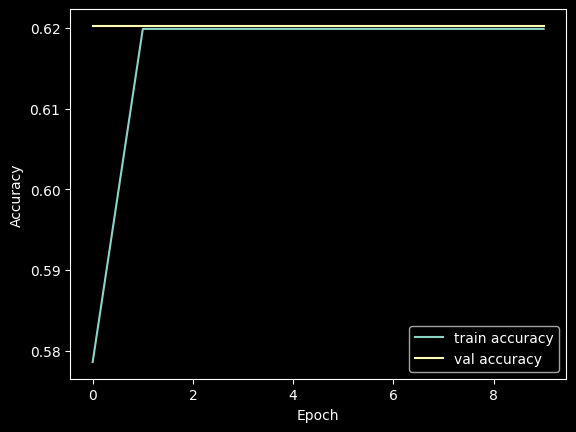

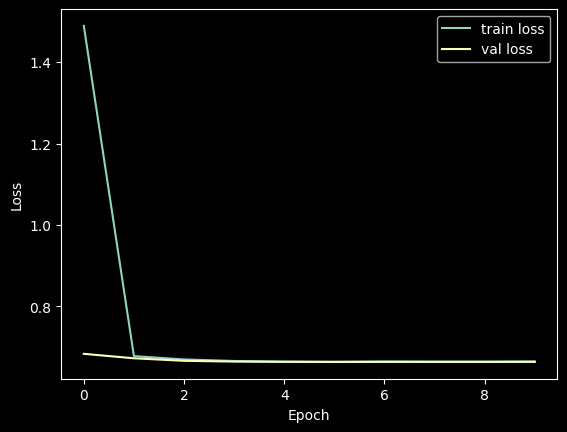

In [18]:
import matplotlib.pyplot as plt

plt.plot(history_simple.history["accuracy"], label="train accuracy")
plt.plot(history_simple.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history_simple.history["loss"], label="train loss")
plt.plot(history_simple.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

hmm weird its 62% and healthy plants are 62% of the whole set let me check cofusion metrix

In [22]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

     healthy       0.62      1.00      0.77       570
    stressed       0.00      0.00      0.00       350

    accuracy                           0.62       920
   macro avg       0.31      0.50      0.38       920
weighted avg       0.38      0.62      0.47       920



it is really guessing healthy all the time dammm...

In [26]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(0.8066215199398044), 1: np.float64(1.3153374233128834)}


In [27]:
history_simple_weighted = simple_nn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.6199 - loss: 0.7095 - val_accuracy: 0.6202 - val_loss: 0.6720
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6199 - loss: 0.6972 - val_accuracy: 0.6202 - val_loss: 0.6799
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.6199 - loss: 0.6944 - val_accuracy: 0.6202 - val_loss: 0.6846
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.6199 - loss: 0.6938 - val_accuracy: 0.6202 - val_loss: 0.6881
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.6070 - loss: 0.6933 - val_accuracy: 0.6202 - val_loss: 0.6905
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.5984 - loss: 0.6932 - val_accuracy: 0.6202 - val_loss: 0.6916
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.4995 - loss: 0.6932 - val_accuracy: 0.3798 - val_loss: 0.6932
Epoch 8/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.5343 - loss: 0.6933 - val_accu

In [29]:
y_pred_prob = simple_nn.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
              precision    recall  f1-score   support

     healthy       0.00      0.00      0.00       570
    stressed       0.38      1.00      0.55       350

    accuracy                           0.38       920
   macro avg       0.19      0.50      0.28       920
weighted avg       0.14      0.38      0.21       920



In [30]:
print(confusion_matrix(y_test, y_pred))
print(label_encoder.classes_)

[[  0 570]
 [  0 350]]
['healthy' 'stressed']


In [31]:
print(y_pred_prob[:20])
print("min:", y_pred_prob.min())
print("max:", y_pred_prob.max())
print("mean:", y_pred_prob.mean())

[[0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]
 [0.5010954]]
min: 0.5010954
max: 0.5010954
mean: 0.50109535


In [32]:
print("X shape:", X.shape)
print("X min:", X.min())
print("X max:", X.max())
print("X mean:", X.mean())
print("X std:", X.std())

print("First image mean:", X[0].mean())
print("Second image mean:", X[1].mean())
print("Difference between first and second:", abs(X[0] - X[1]).sum())

X shape: (6127, 128, 128, 3)
X min: 0.0
X max: 1.0
X mean: 0.3716375
X std: 0.21651387
First image mean: 0.391816
Second image mean: 0.3405184
Difference between first and second: 10733.863


wow now it guessing everything stressed wow
okay wont waste my time on snn i will try cnn now

In [33]:
cnn = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(1, activation="sigmoid")
])

cnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history_cnn = cnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 26s 182ms/step - accuracy: 0.6157 - loss: 0.6738 - val_accuracy: 0.6202 - val_loss: 0.6756
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 23s 169ms/step - accuracy: 0.6381 - loss: 0.6515 - val_accuracy: 0.6910 - val_loss: 0.6007
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 23s 170ms/step - accuracy: 0.6593 - loss: 0.6266 - val_accuracy: 0.6877 - val_loss: 0.6071
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 22s 168ms/step - accuracy: 0.6957 - loss: 0.5949 - val_accuracy: 0.7301 - val_loss: 0.5638
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 22s 167ms/step - accuracy: 0.7029 - loss: 0.5850 - val_accuracy: 0.7225 - val_loss: 0.5609
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 22s 165ms/step - accuracy: 0.7094 - loss: 0.5813 - val_accuracy: 0.7247 - val_loss: 0.5730
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 22s 166ms/step - accuracy: 0.7379 - loss: 0.5443 - val_accuracy: 0.7530 - val_loss: 0.5337
Epoch 8/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 22s 167ms/step - accuracy: 0.7481 - loss: 0

In [35]:

y_pred_prob = cnn.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

print(confusion_matrix(y_test, y_pred))
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
[[473  97]
 [170 180]]
              precision    recall  f1-score   support

     healthy       0.74      0.83      0.78       570
    stressed       0.65      0.51      0.57       350

    accuracy                           0.71       920
   macro avg       0.69      0.67      0.68       920
weighted avg       0.70      0.71      0.70       920



In [36]:
print(y_pred_prob[:20])
print("min:", y_pred_prob.min())
print("max:", y_pred_prob.max())
print("mean:", y_pred_prob.mean())

[[0.41839162]
 [0.74747926]
 [0.9690691 ]
 [0.0475174 ]
 [0.0991216 ]
 [0.00158969]
 [0.14463602]
 [0.16715878]
 [0.17694533]
 [0.16444735]
 [0.8703598 ]
 [0.62379766]
 [0.79490197]
 [0.91334206]
 [0.163324  ]
 [0.17645226]
 [0.209013  ]
 [0.752151  ]
 [0.7396826 ]
 [0.235636  ]]
min: 0.0015896902
max: 0.9979112
mean: 0.3752023


The CNN achieved a test accuracy of 71%, which is higher than the SNN baseline. More importantly, the CNN predicted both healthy and stressed classes, while the SNN collapsed into predicting only one class. The CNN reached a stressed recall of 0.51 and stressed F1-score of 0.57, showing that convolutional layers were able to learn more useful visual patterns from the plant images. However, the model still misclassified 170 stressed plants as healthy, meaning that further improvement is needed for reliable stress detection.

now onto cnn with class weight

In [37]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights_array))
print(class_weights)

{0: np.float64(0.8066215199398044), 1: np.float64(1.3153374233128834)}


In [39]:
cnn_weighted = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(1, activation="sigmoid")
])

cnn_weighted.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [40]:
history_cnn_weighted = cnn_weighted.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 26s 181ms/step - accuracy: 0.4942 - loss: 0.6914 - val_accuracy: 0.6594 - val_loss: 0.6407
Epoch 2/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 24s 177ms/step - accuracy: 0.5732 - loss: 0.6894 - val_accuracy: 0.6202 - val_loss: 0.6836
Epoch 3/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 23s 175ms/step - accuracy: 0.6192 - loss: 0.6932 - val_accuracy: 0.6202 - val_loss: 0.6909
Epoch 4/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 23s 173ms/step - accuracy: 0.5746 - loss: 0.6910 - val_accuracy: 0.5963 - val_loss: 0.6747
Epoch 5/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 24s 176ms/step - accuracy: 0.6383 - loss: 0.6594 - val_accuracy: 0.7116 - val_loss: 0.6370
Epoch 6/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 24s 176ms/step - accuracy: 0.6709 - loss: 0.6365 - val_accuracy: 0.6866 - val_loss: 0.6414
Epoch 7/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 24s 180ms/step - accuracy: 0.6849 - loss: 0.6265 - val_accuracy: 0.7084 - val_loss: 0.6061
Epoch 8/10
134/134 ━━━━━━━━━━━━━━━━━━━━ 24s 177ms/step - accuracy: 0.6915 - loss: 0

In [41]:

y_pred_prob = cnn_weighted.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

print(confusion_matrix(y_test, y_pred))
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step
[[422 148]
 [146 204]]
              precision    recall  f1-score   support

     healthy       0.74      0.74      0.74       570
    stressed       0.58      0.58      0.58       350

    accuracy                           0.68       920
   macro avg       0.66      0.66      0.66       920
weighted avg       0.68      0.68      0.68       920



## Model Evaluation Summary

| Model | Accuracy | Healthy F1 | Stressed F1 | Stressed Recall |
|---|---:|---:|---:|---:|
| Majority baseline | 0.62 | 0.77 | 0.00 | 0.00 |
| SNN | 0.62 | 0.77 | 0.00 | 0.00 |
| SNN + class weights | 0.38 | 0.00 | 0.55 | 1.00 |
| CNN | 0.71 | 0.78 | 0.57 | 0.51 |
| CNN + class weights | 0.68 | 0.74 | 0.58 | 0.58 |

### Interpretation

The SNN performed similarly to the majority baseline because it predicted only the healthy class.
After applying class weights, the SNN overcorrected and predicted only the stressed class.

The CNN performed better because it was able to learn visual patterns from the images and predict both classes.
The CNN with class weights had lower accuracy, but improved stressed recall from **0.51** to **0.58**, meaning it detected more stressed plants.

okay now bc i dont know AI told me that next step that i could try is data augmentation

In [42]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

In [43]:
cnn_augmented = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(1, activation="sigmoid")
])

cnn_augmented.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [53]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [54]:
history_cnn_augmented = cnn_augmented.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 27s 200ms/step - accuracy: 0.6451 - loss: 0.6483 - val_accuracy: 0.7160 - val_loss: 0.5931
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 26s 197ms/step - accuracy: 0.6721 - loss: 0.6223 - val_accuracy: 0.6801 - val_loss: 0.6306
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 27s 197ms/step - accuracy: 0.6838 - loss: 0.6143 - val_accuracy: 0.7280 - val_loss: 0.5535
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 26s 191ms/step - accuracy: 0.7041 - loss: 0.5999 - val_accuracy: 0.7367 - val_loss: 0.5469
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 28s 209ms/step - accuracy: 0.6999 - loss: 0.5867 - val_accuracy: 0.7519 - val_loss: 0.5472
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 30s 226ms/step - accuracy: 0.7101 - loss: 0.5800 - val_accuracy: 0.7410 - val_loss: 0.5286
Epoch 7/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 27s 202ms/step - accuracy: 0.7141 - loss: 0.5663 - val_accuracy: 0.7650 - val_loss: 0.5134
Epoch 8/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 27s 200ms/step - accuracy: 0.7316 - loss: 0

In [55]:
test_loss, test_acc = cnn_augmented.evaluate(X_test, y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7924 - loss: 0.4270
Test loss: 0.42702507972717285
Test accuracy: 0.792391300201416


In [56]:
y_pred_prob = cnn_augmented.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step


In [57]:
print(confusion_matrix(y_test, y_pred))

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

[[479  91]
 [100 250]]
              precision    recall  f1-score   support

     healthy       0.83      0.84      0.83       570
    stressed       0.73      0.71      0.72       350

    accuracy                           0.79       920
   macro avg       0.78      0.78      0.78       920
weighted avg       0.79      0.79      0.79       920



In [58]:
print(confusion_matrix(y_test, y_pred))
print(label_encoder.classes_)

[[479  91]
 [100 250]]
['healthy' 'stressed']


i will save this model

In [59]:
cnn_augmented.save("plant_stress_cnn.keras")

In [60]:
import json

with open("label_classes.json", "w") as f:
    json.dump(label_encoder.classes_.tolist(), f)

i had idea bc in our dataset we have also the mask. we could try to multyply the images with the mask so they would have higher value to like highlight to model where atcually is the plant. just idea but it could work

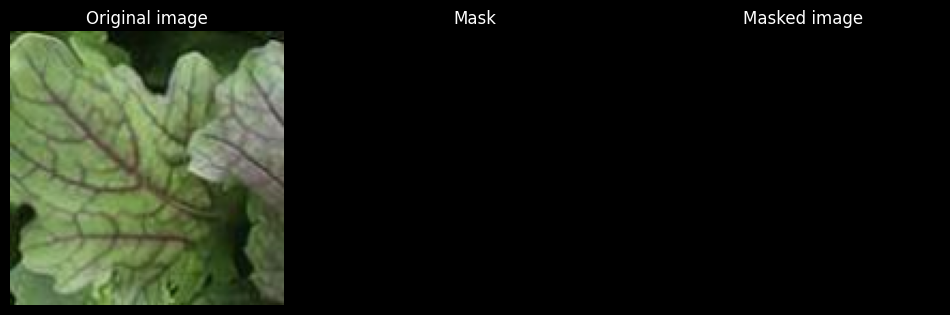

Label: healthy
Crop type: idb


In [61]:
IMG_SIZE = 128

def decode_image(image_dict):
    img = Image.open(BytesIO(image_dict["bytes"])).convert("RGB")
    img = img.resize((IMG_SIZE, IMG_SIZE))
    return np.array(img)

def decode_mask(mask_dict):
    mask = Image.open(BytesIO(mask_dict["bytes"])).convert("L")
    mask = mask.resize((IMG_SIZE, IMG_SIZE))
    mask = np.array(mask)

    # Convert mask to 0-1
    mask = mask.astype("float32") / 255.0

    # Make it shape: 128 x 128 x 1
    mask = np.expand_dims(mask, axis=-1)

    return mask

row = df.iloc[0]

img = decode_image(row["image"])
mask = decode_mask(row["mask"])

masked_img = img.astype("float32") * mask

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img.astype("uint8"))
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(masked_img.astype("uint8"))
plt.title("Masked image")
plt.axis("off")

plt.show()

print("Label:", row["label"])
print("Crop type:", row["crop_type"])


In [62]:
def decode_masked_image(row):
    img = decode_image(row["image"]).astype("float32") / 255.0
    mask = decode_mask(row["mask"])

    masked_img = img * mask

    return masked_img

X_masked = np.stack(df.apply(decode_masked_image, axis=1).values)

print(X_masked.shape)
print(X_masked.min(), X_masked.max())

(6127, 128, 128, 3)
0.0 1.0


In [63]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["label"])

print(label_encoder.classes_)

['healthy' 'stressed']


In [64]:
X_train_m, X_temp_m, y_train_m, y_temp_m = train_test_split(
    X_masked,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_m, X_test_m, y_val_m, y_test_m = train_test_split(
    X_temp_m,
    y_temp_m,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_m
)

print("Train:", X_train_m.shape)
print("Validation:", X_val_m.shape)
print("Test:", X_test_m.shape)

Train: (4288, 128, 128, 3)
Validation: (919, 128, 128, 3)
Test: (920, 128, 128, 3)


In [65]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

cnn_masked = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(1, activation="sigmoid")
])

cnn_masked.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_masked = cnn_masked.fit(
    X_train_m,
    y_train_m,
    validation_data=(X_val_m, y_val_m),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 29s 191ms/step - accuracy: 0.9109 - loss: 0.4657 - val_accuracy: 0.9260 - val_loss: 0.4462
Epoch 2/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 25s 188ms/step - accuracy: 0.9286 - loss: 0.4294 - val_accuracy: 0.9260 - val_loss: 0.4162
Epoch 3/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 25s 184ms/step - accuracy: 0.9291 - loss: 0.4003 - val_accuracy: 0.9260 - val_loss: 0.3903
Epoch 4/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 25s 186ms/step - accuracy: 0.9291 - loss: 0.3758 - val_accuracy: 0.9260 - val_loss: 0.3677
Epoch 5/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 24s 182ms/step - accuracy: 0.9289 - loss: 0.3549 - val_accuracy: 0.9260 - val_loss: 0.3482
Epoch 6/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 26s 196ms/step - accuracy: 0.9293 - loss: 0.3360 - val_accuracy: 0.9260 - val_loss: 0.3313
Epoch 7/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 25s 184ms/step - accuracy: 0.9284 - loss: 0.3212 - val_accuracy: 0.9260 - val_loss: 0.3170
Epoch 8/30
134/134 ━━━━━━━━━━━━━━━━━━━━ 24s 183ms/step - accuracy: 0.9284 - loss: 0

In [66]:

test_loss, test_acc = cnn_masked.evaluate(X_test_m, y_test_m)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

y_pred_prob_m = cnn_masked.predict(X_test_m)
y_pred_m = (y_pred_prob_m > 0.5).astype(int).reshape(-1)

print(confusion_matrix(y_test_m, y_pred_m))

print(classification_report(
    y_test_m,
    y_pred_m,
    target_names=label_encoder.classes_,
    zero_division=0
))

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.9196 - loss: 0.2498
Test loss: 0.2497766613960266
Test accuracy: 0.9195652008056641
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
[[570   0]
 [ 74 276]]
              precision    recall  f1-score   support

     healthy       0.89      1.00      0.94       570
    stressed       1.00      0.79      0.88       350

    accuracy                           0.92       920
   macro avg       0.94      0.89      0.91       920
weighted avg       0.93      0.92      0.92       920



In [67]:
print(confusion_matrix(y_test_m, y_pred_m))
print(label_encoder.classes_)

[[570   0]
 [ 74 276]]
['healthy' 'stressed']
